# Sensor Degradation Detection via Signal Quality Analysis in Industrial Processes

**Author:** Rishabh Goenka
**Course:** EE 344 — Data-Driven Modeling and Machine Learning (Winter 2026)
**Dataset:** Tennessee Eastman Process (TEP) Simulation — Rieth et al. (2017)

---

## Problem Statement

Modern industrial plants rely on dozens of sensors to monitor temperature, pressure, flow rates, and chemical concentrations. When sensors degrade — through noise, drift, or sticking — the system continues to trust faulty readings, causing poor control decisions and safety risks.

This project detects and classifies sensor/process faults in the Tennessee Eastman Process simulation using **signal quality features** rather than raw values. Three feature extraction pipelines are compared:

1. **Statistical features** — mean, std, skewness, kurtosis, min, max per sensor per time window
2. **Wavelet features** — multi-level DWT decomposition with energy, entropy, and magnitude
3. **Combined** — union of both

These features are evaluated across **supervised classifiers** (Logistic Regression, Random Forest, SVM, XGBoost) for binary and multi-class fault detection, and **one-class methods** (Isolation Forest, Autoencoder) trained only on normal data.

**Primary metric:** Macro F1-score
**Evaluation:** Run-level stratified 5-fold cross-validation to prevent temporal data leakage

## 1) Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, time

import pywt
from scipy.stats import skew, kurtosis

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import LinearSVC
import xgboost as xgb

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, roc_curve, roc_auc_score,
    precision_recall_fscore_support
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cpu


In [2]:
# ============================================================
# Configuration
# ============================================================

DATA_DIR = "data"

WINDOW_SIZE = 30        # 30 samples = 90 min at 3-min intervals
STRIDE = 10             # 10 samples = 30 min

WAVELET = "db4"         # Daubechies-4
WAVELET_LEVEL = 3       # 3 decomposition levels

N_FOLDS = 5             # 5-fold cross-validation

FAULT_START_TRAIN = 20  # 1-indexed sample where fault begins in training runs
FAULT_START_TEST = 160  # 1-indexed sample where fault begins in testing runs

# Subsample runs per fault type for tractable runtime / memory.
# Set to None to use all 500 runs (~20 GB RAM required).
SUBSAMPLE_RUNS = 50

## 2) Load Data

The TEP dataset consists of four files (converted from `.RData` to `.parquet` for portability):
- **TEP_FaultFree_Training** — 500 normal runs, 500 samples each
- **TEP_FaultFree_Testing** — 500 normal runs, 960 samples each
- **TEP_Faulty_Training** — 20 fault types × 500 runs × 500 samples
- **TEP_Faulty_Testing** — 20 fault types × 500 runs × 960 samples

Each sample contains 52 process variables: 41 measured (`xmeas`) and 11 manipulated (`xmv`), recorded at 3-minute intervals.

In [3]:
print("Loading parquet files ...")
t0 = time.time()
ff_train = pd.read_parquet(os.path.join(DATA_DIR, "TEP_FaultFree_Training.parquet"))
ff_test  = pd.read_parquet(os.path.join(DATA_DIR, "TEP_FaultFree_Testing.parquet"))
f_train  = pd.read_parquet(os.path.join(DATA_DIR, "TEP_Faulty_Training.parquet"))
f_test   = pd.read_parquet(os.path.join(DATA_DIR, "TEP_Faulty_Testing.parquet"))
print(f"Loaded in {time.time() - t0:.1f}s")

for name, df in [("FaultFree Train", ff_train), ("FaultFree Test", ff_test),
                 ("Faulty Train", f_train), ("Faulty Test", f_test)]:
    print(f"  {name:16s}: shape={df.shape}")

Loading parquet files ...
Loaded in 6.4s
  FaultFree Train : shape=(250000, 55)
  FaultFree Test  : shape=(480000, 55)
  Faulty Train    : shape=(5000000, 55)
  Faulty Test     : shape=(9600000, 55)


In [4]:
print("=== Fault-Free Training ===")
print("Columns:", ff_train.columns.tolist())
print()
display(ff_train.head(3))

print()
print("=== Faulty Training ===")
print("Columns:", f_train.columns.tolist())
print()
display(f_train.head(3))

=== Fault-Free Training ===
Columns: ['faultNumber', 'simulationRun', 'sample', 'xmeas_1', 'xmeas_2', 'xmeas_3', 'xmeas_4', 'xmeas_5', 'xmeas_6', 'xmeas_7', 'xmeas_8', 'xmeas_9', 'xmeas_10', 'xmeas_11', 'xmeas_12', 'xmeas_13', 'xmeas_14', 'xmeas_15', 'xmeas_16', 'xmeas_17', 'xmeas_18', 'xmeas_19', 'xmeas_20', 'xmeas_21', 'xmeas_22', 'xmeas_23', 'xmeas_24', 'xmeas_25', 'xmeas_26', 'xmeas_27', 'xmeas_28', 'xmeas_29', 'xmeas_30', 'xmeas_31', 'xmeas_32', 'xmeas_33', 'xmeas_34', 'xmeas_35', 'xmeas_36', 'xmeas_37', 'xmeas_38', 'xmeas_39', 'xmeas_40', 'xmeas_41', 'xmv_1', 'xmv_2', 'xmv_3', 'xmv_4', 'xmv_5', 'xmv_6', 'xmv_7', 'xmv_8', 'xmv_9', 'xmv_10', 'xmv_11']



,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
0,0.0,1.0,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,...,53.744,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447
1,0.0,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,...,53.414,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194
2,0.0,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,...,54.357,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530



=== Faulty Training ===
Columns: ['faultNumber', 'simulationRun', 'sample', 'xmeas_1', 'xmeas_2', 'xmeas_3', 'xmeas_4', 'xmeas_5', 'xmeas_6', 'xmeas_7', 'xmeas_8', 'xmeas_9', 'xmeas_10', 'xmeas_11', 'xmeas_12', 'xmeas_13', 'xmeas_14', 'xmeas_15', 'xmeas_16', 'xmeas_17', 'xmeas_18', 'xmeas_19', 'xmeas_20', 'xmeas_21', 'xmeas_22', 'xmeas_23', 'xmeas_24', 'xmeas_25', 'xmeas_26', 'xmeas_27', 'xmeas_28', 'xmeas_29', 'xmeas_30', 'xmeas_31', 'xmeas_32', 'xmeas_33', 'xmeas_34', 'xmeas_35', 'xmeas_36', 'xmeas_37', 'xmeas_38', 'xmeas_39', 'xmeas_40', 'xmeas_41', 'xmv_1', 'xmv_2', 'xmv_3', 'xmv_4', 'xmv_5', 'xmv_6', 'xmv_7', 'xmv_8', 'xmv_9', 'xmv_10', 'xmv_11']



,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
0,1,1.0,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,...,53.744,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447
1,1,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,...,53.414,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194
2,1,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,...,54.357,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530


In [5]:
# Identify sensor columns (everything except metadata)
meta_cols = ["faultNumber", "simulationRun", "sample"]
sensor_cols = [c for c in f_train.columns if c not in meta_cols]
print(f"Sensor columns ({len(sensor_cols)}): {sensor_cols[:5]} ... {sensor_cols[-3:]}")

# Ensure fault-free data has faultNumber = 0
if "faultNumber" not in ff_train.columns:
    ff_train["faultNumber"] = 0
    ff_test["faultNumber"] = 0
else:
    ff_train["faultNumber"] = ff_train["faultNumber"].fillna(0).astype(int)
    ff_test["faultNumber"] = ff_test["faultNumber"].fillna(0).astype(int)

# Combine into single train / test DataFrames
train_df = pd.concat([ff_train, f_train], ignore_index=True)
test_df  = pd.concat([ff_test,  f_test],  ignore_index=True)

# Cast metadata columns to int
for col in meta_cols:
    if col in train_df.columns:
        train_df[col] = train_df[col].astype(int)
        test_df[col]  = test_df[col].astype(int)

# Subsample runs if configured
if SUBSAMPLE_RUNS is not None:
    def subsample_runs(df, n):
        parts = []
        for fn in sorted(df["faultNumber"].unique()):
            sub = df[df["faultNumber"] == fn]
            runs = sub["simulationRun"].unique()
            if len(runs) > n:
                runs = np.random.choice(runs, n, replace=False)
                sub = sub[sub["simulationRun"].isin(runs)]
            parts.append(sub)
        return pd.concat(parts, ignore_index=True)

    train_df = subsample_runs(train_df, SUBSAMPLE_RUNS)
    test_df  = subsample_runs(test_df,  SUBSAMPLE_RUNS)
    print(f"Subsampled to {SUBSAMPLE_RUNS} runs per fault type")

print(f"Training shape: {train_df.shape}")
print(f"Testing shape:  {test_df.shape}")

Sensor columns (52): ['xmeas_1', 'xmeas_2', 'xmeas_3', 'xmeas_4', 'xmeas_5'] ... ['xmv_9', 'xmv_10', 'xmv_11']
Subsampled to 50 runs per fault type
Training shape: (525000, 55)
Testing shape:  (1008000, 55)


## 3) Data Audit

Verify data integrity: missing values, label distribution, simulation run counts, and sensor column count.

In [6]:
print("=== Missing Values ===")
print(f"Training NaN count:  {train_df.isna().sum().sum()}")
print(f"Testing NaN count:   {test_df.isna().sum().sum()}")
print(f"Training Inf count:  {np.isinf(train_df[sensor_cols].values).sum()}")
print(f"Testing Inf count:   {np.isinf(test_df[sensor_cols].values).sum()}")
print(f"Training duplicates: {train_df.duplicated().sum()}")
print()

print("=== Fault Types & Run Counts (Training) ===")
run_counts = train_df.groupby("faultNumber")["simulationRun"].nunique()
sample_counts = train_df["faultNumber"].value_counts().sort_index()
audit_df = pd.DataFrame({"Runs": run_counts, "Samples": sample_counts})
print(audit_df.to_string())
print()

print(f"Sensor columns: {len(sensor_cols)} (expected 52)")
print(f"Sample range — training: {train_df['sample'].min()} to {train_df['sample'].max()}")
print(f"Sample range — testing:  {test_df['sample'].min()} to {test_df['sample'].max()}")

=== Missing Values ===
Training NaN count:  0
Testing NaN count:   0
Training Inf count:  0
Testing Inf count:   0
Training duplicates: 0

=== Fault Types & Run Counts (Training) ===
             Runs  Samples
faultNumber               
0              50    25000
1              50    25000
2              50    25000
3              50    25000
4              50    25000
5              50    25000
6              50    25000
7              50    25000
8              50    25000
9              50    25000
10             50    25000
11             50    25000
12             50    25000
13             50    25000
14             50    25000
15             50    25000
16             50    25000
17             50    25000
18             50    25000
19             50    25000
20             50    25000

Sensor columns: 52 (expected 52)
Sample range — training: 1 to 500
Sample range — testing:  1 to 960


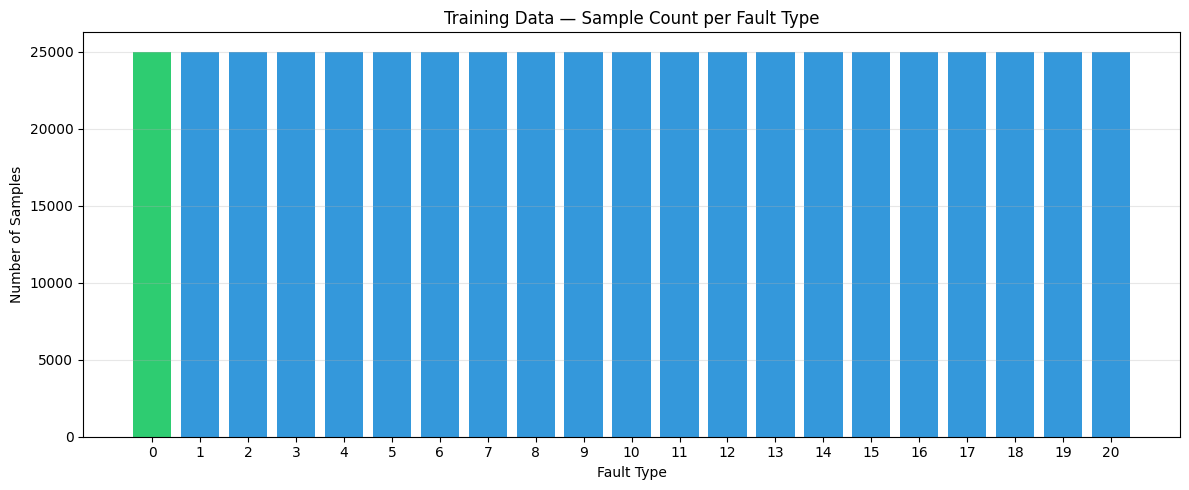

Binary balance: Normal = 25,000 (4.8%), Faulty = 500,000 (95.2%)


In [7]:
# Class distribution bar chart
fig, ax = plt.subplots(figsize=(12, 5))
counts = train_df["faultNumber"].value_counts().sort_index()
colors = ["#2ecc71" if i == 0 else "#3498db" for i in counts.index]
ax.bar(counts.index.astype(str), counts.values, color=colors)
ax.set_xlabel("Fault Type")
ax.set_ylabel("Number of Samples")
ax.set_title("Training Data — Sample Count per Fault Type")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

n_normal = (train_df["faultNumber"] == 0).sum()
n_faulty = (train_df["faultNumber"] != 0).sum()
print(f"Binary balance: Normal = {n_normal:,} ({100*n_normal/len(train_df):.1f}%), "
      f"Faulty = {n_faulty:,} ({100*n_faulty/len(train_df):.1f}%)")

## 4) Exploratory Data Analysis

Visualize sensor behavior under normal and faulty conditions, examine correlations, and assess initial separability with PCA.

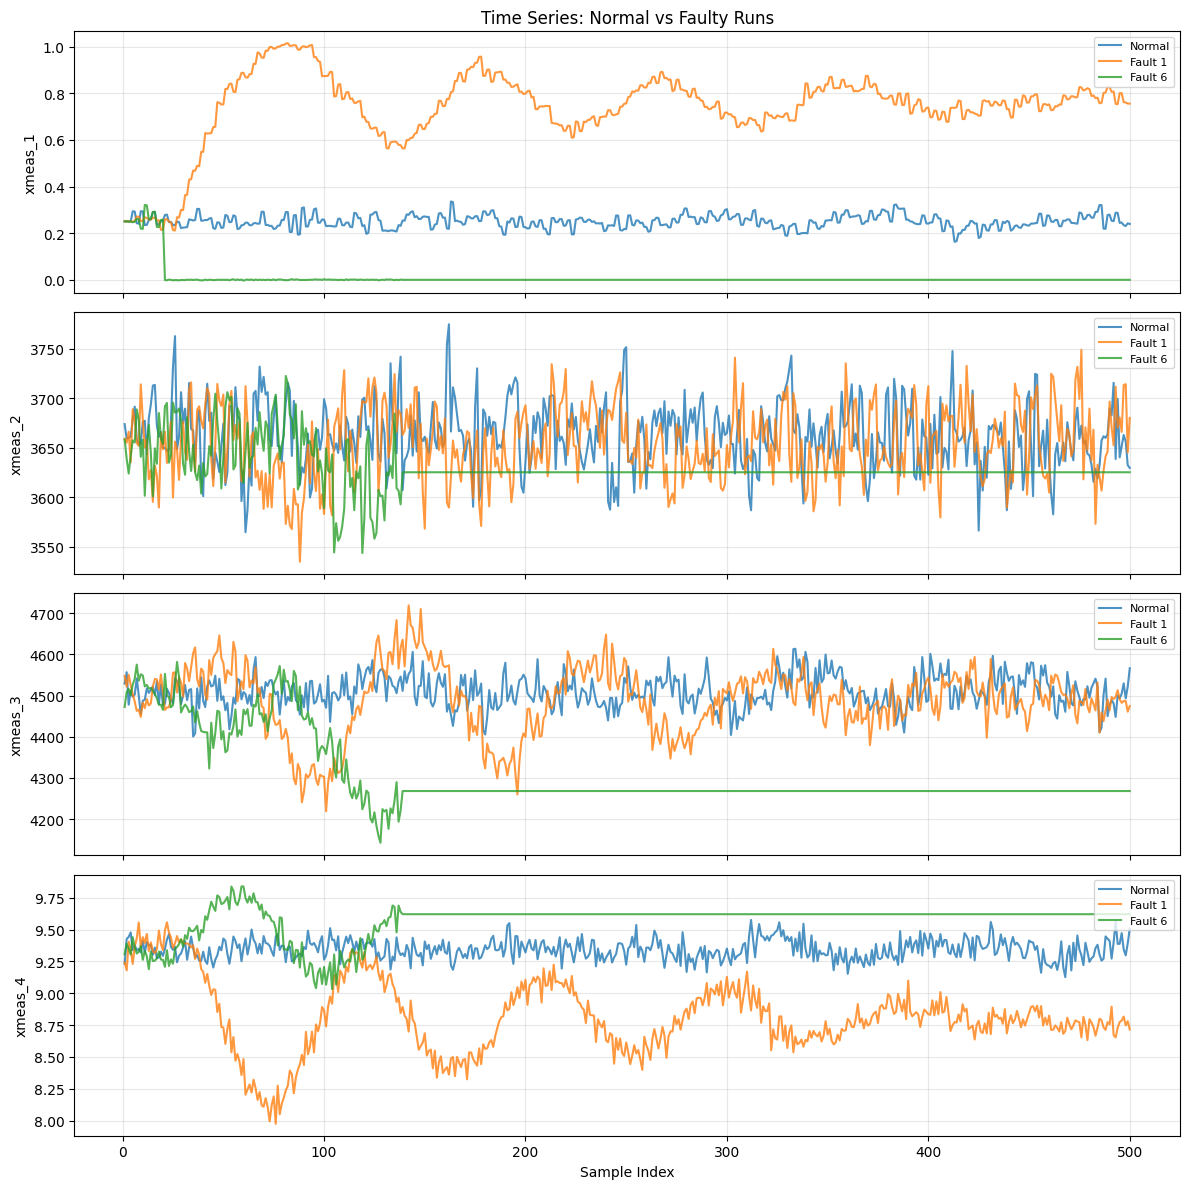

In [8]:
# Time series: Normal vs Faulty runs for representative sensors
run0 = train_df[train_df["faultNumber"] == 0]["simulationRun"].unique()[0]
run1 = train_df[train_df["faultNumber"] == 1]["simulationRun"].unique()[0]
run6 = train_df[train_df["faultNumber"] == 6]["simulationRun"].unique()[0]

normal_run = train_df[(train_df["faultNumber"] == 0) & (train_df["simulationRun"] == run0)]
fault1_run = train_df[(train_df["faultNumber"] == 1) & (train_df["simulationRun"] == run1)]
fault6_run = train_df[(train_df["faultNumber"] == 6) & (train_df["simulationRun"] == run6)]

plot_sensors = sensor_cols[:4]

fig, axes = plt.subplots(len(plot_sensors), 1, figsize=(12, 3 * len(plot_sensors)), sharex=True)
for i, sensor in enumerate(plot_sensors):
    axes[i].plot(normal_run["sample"].values, normal_run[sensor].values, label="Normal", alpha=0.8)
    axes[i].plot(fault1_run["sample"].values, fault1_run[sensor].values, label="Fault 1", alpha=0.8)
    axes[i].plot(fault6_run["sample"].values, fault6_run[sensor].values, label="Fault 6", alpha=0.8)
    axes[i].set_ylabel(sensor)
    axes[i].legend(loc="upper right", fontsize=8)
    axes[i].grid(True, alpha=0.3)
axes[-1].set_xlabel("Sample Index")
axes[0].set_title("Time Series: Normal vs Faulty Runs")
plt.tight_layout()
plt.show()

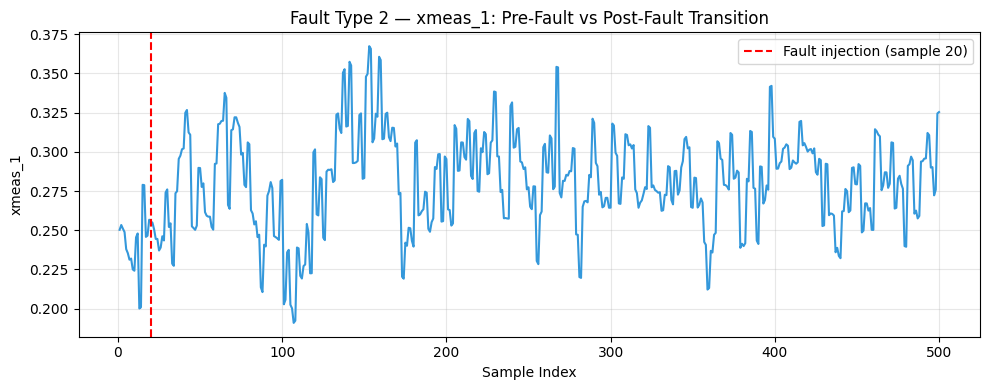

In [9]:
# Fault injection timing visualization
fault2_run_id = train_df[train_df["faultNumber"] == 2]["simulationRun"].unique()[0]
fault2_run = train_df[(train_df["faultNumber"] == 2) & (train_df["simulationRun"] == fault2_run_id)]
sensor = sensor_cols[0]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(fault2_run["sample"].values, fault2_run[sensor].values, color="#3498db")
ax.axvline(x=FAULT_START_TRAIN, color="red", linestyle="--",
           label=f"Fault injection (sample {FAULT_START_TRAIN})")
ax.set_xlabel("Sample Index")
ax.set_ylabel(sensor)
ax.set_title(f"Fault Type 2 — {sensor}: Pre-Fault vs Post-Fault Transition")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

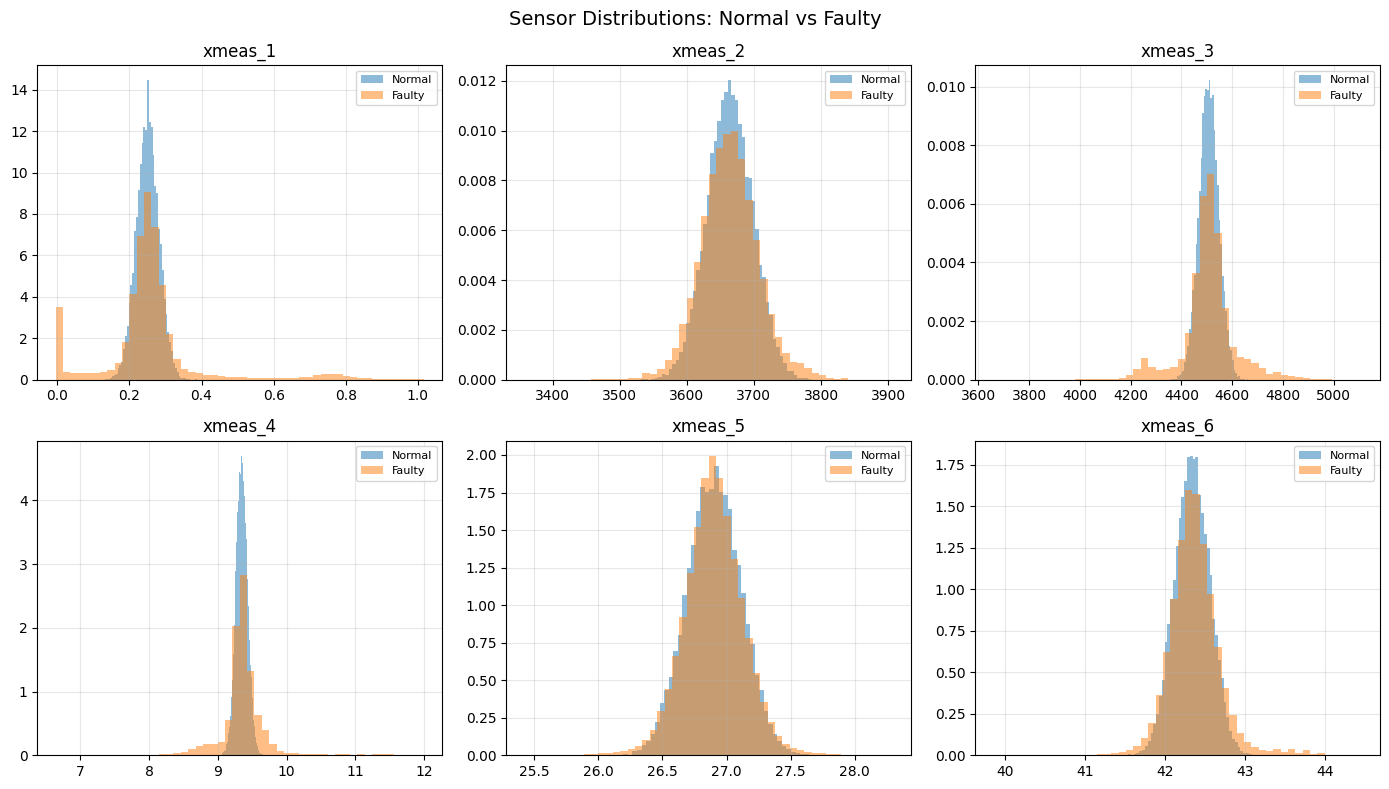

In [10]:
# Sensor distributions: Normal vs Faulty
normal_data = train_df[train_df["faultNumber"] == 0]
faulty_data = train_df[train_df["faultNumber"] != 0]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for idx, sensor in enumerate(sensor_cols[:6]):
    ax = axes[idx // 3, idx % 3]
    ax.hist(normal_data[sensor].values, bins=50, alpha=0.5, label="Normal", density=True)
    ax.hist(faulty_data[sensor].values, bins=50, alpha=0.5, label="Faulty", density=True)
    ax.set_title(sensor)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
fig.suptitle("Sensor Distributions: Normal vs Faulty", fontsize=14)
plt.tight_layout()
plt.show()

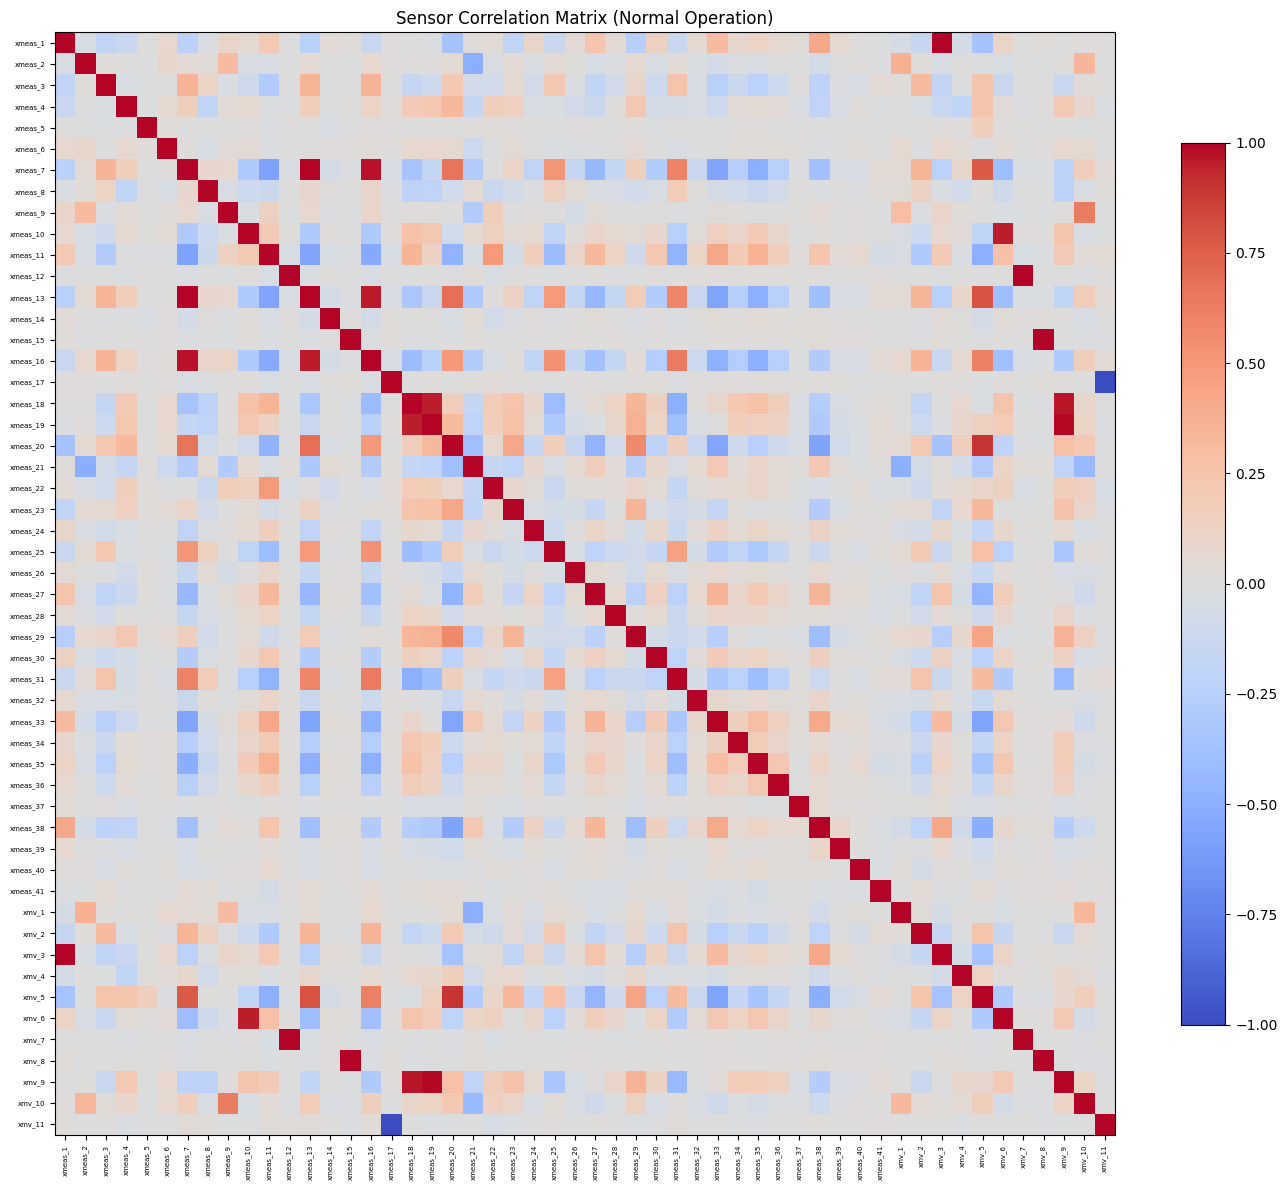

In [11]:
# Sensor correlation matrix (normal operation)
corr = train_df[train_df["faultNumber"] == 0][sensor_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(sensor_cols)))
ax.set_yticks(range(len(sensor_cols)))
ax.set_xticklabels(sensor_cols, rotation=90, fontsize=5)
ax.set_yticklabels(sensor_cols, fontsize=5)
ax.set_title("Sensor Correlation Matrix (Normal Operation)")
plt.tight_layout()
plt.show()

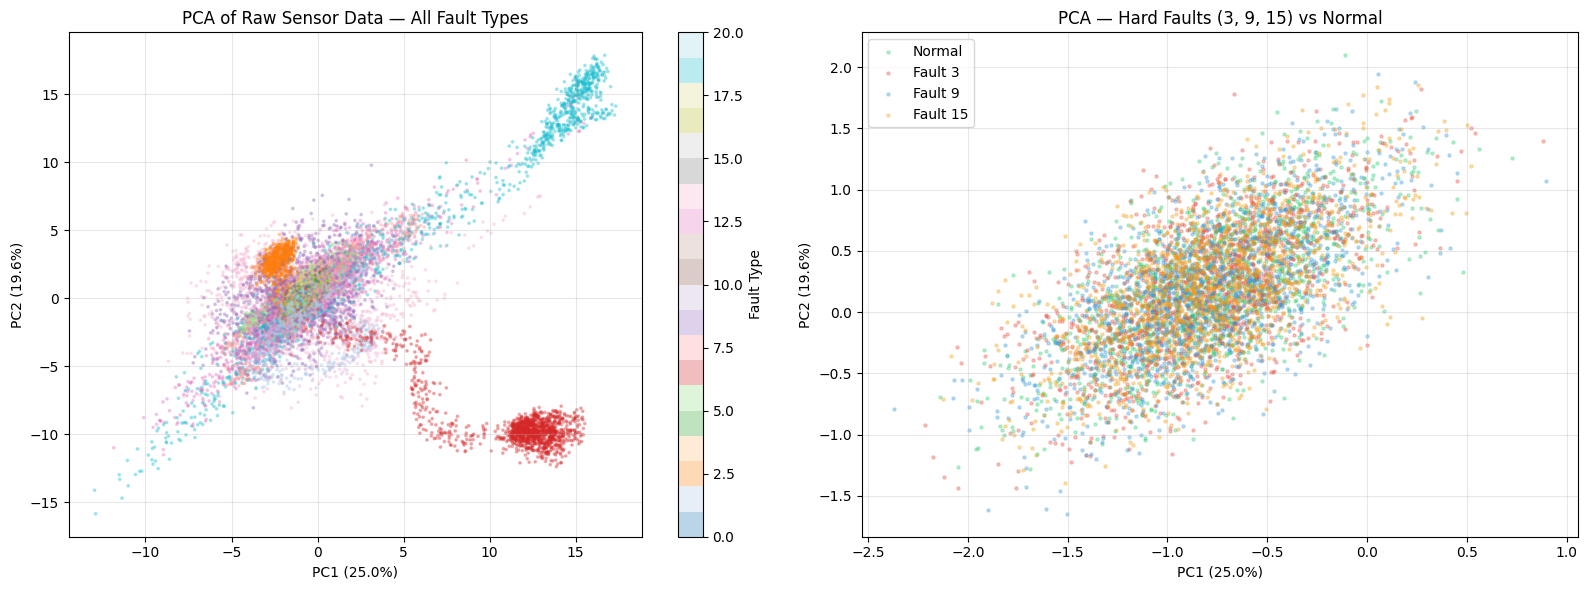

In [12]:
# PCA on raw sensor data (subsampled for visualization)
n_pca_sample = min(30000, len(train_df))
pca_idx = np.random.choice(len(train_df), n_pca_sample, replace=False)
X_pca = train_df.iloc[pca_idx][sensor_cols].values
y_pca = train_df.iloc[pca_idx]["faultNumber"].values

scaler_viz = StandardScaler()
X_pca_scaled = scaler_viz.fit_transform(X_pca)
pca_viz = PCA(n_components=2)
X_2d = pca_viz.fit_transform(X_pca_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y_pca,
                          cmap="tab20", alpha=0.3, s=3)
plt.colorbar(scatter, ax=axes[0], label="Fault Type")
axes[0].set_xlabel(f"PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title("PCA of Raw Sensor Data — All Fault Types")
axes[0].grid(True, alpha=0.3)

# Hard faults (3, 9, 15) vs Normal
hard_mask = np.isin(y_pca, [0, 3, 9, 15])
X_hard = X_2d[hard_mask]
y_hard = y_pca[hard_mask]
cmap_hard = {0: "#2ecc71", 3: "#e74c3c", 9: "#3498db", 15: "#f39c12"}
for fn, label in [(0, "Normal"), (3, "Fault 3"), (9, "Fault 9"), (15, "Fault 15")]:
    m = y_hard == fn
    if m.sum() > 0:
        axes[1].scatter(X_hard[m, 0], X_hard[m, 1], c=cmap_hard[fn],
                        label=label, alpha=0.3, s=5)
axes[1].set_xlabel(f"PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("PCA — Hard Faults (3, 9, 15) vs Normal")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Key EDA Observations

- The 52 sensors show varying degrees of correlation — strong blocks of correlated measurements exist, motivating dimensionality reduction.
- Time series plots show that some faults produce obvious shifts or increased variance, while others (notably faults 3, 9, 15) are much more subtle.
- The PCA scatter plot reveals partial cluster separation for some fault types, but significant overlap remains — especially for the "hard" faults. This motivates wavelet-based feature extraction to capture signal quality characteristics beyond raw values.
- Class balance: each fault type has equal representation, but the binary split (normal vs fault) is heavily imbalanced.

## 5) Windowing and Feature Extraction

### Approach

Each simulation run is segmented into overlapping time windows. From each window, three feature sets are extracted:

| Pipeline | Features per window | Description |
|----------|-------------------|-------------|
| Statistical | 6 × 52 = 312 | mean, std, skewness, kurtosis, min, max per sensor |
| Wavelet | 3 × 4 × 52 = 624 | energy, entropy, mean magnitude from 3-level db4 DWT |
| Combined | 936 | union of statistical and wavelet |

Window labels: a window from a faulty run is labeled as faulty only if more than half its samples are post-injection.

In [13]:
def extract_features(df, sensor_cols, window_size, stride, fault_start):
    """Sliding-window feature extraction with statistical and wavelet pipelines.

    Returns: (stat_features, wav_features, labels, run_ids, run_fault_types)
    """
    stat_feats, wav_feats = [], []
    labels, run_ids, run_faults = [], [], []

    groups = list(df.groupby(["faultNumber", "simulationRun"]))
    n_groups = len(groups)
    t0 = time.time()

    for i, ((fault_num, run_id), group) in enumerate(groups):
        if (i + 1) % 500 == 0 or (i + 1) == n_groups:
            print(f"  Run {i+1}/{n_groups}  ({time.time()-t0:.0f}s)")

        group = group.sort_values("sample")
        values = group[sensor_cols].values.astype(np.float64)
        samples = group["sample"].values
        n = len(values)

        for start in range(0, n - window_size + 1, stride):
            w = values[start:start + window_size]
            s = samples[start:start + window_size]

            # Label assignment with fault-injection boundary handling
            if fault_num == 0:
                label = 0
            else:
                label = int(fault_num) if np.sum(s >= fault_start) > window_size // 2 else 0

            # Statistical features: (6 * n_sensors,)
            # nan_policy='omit' + fillna handles constant-value windows
            sf = np.concatenate([
                np.mean(w, axis=0), np.std(w, axis=0),
                np.nan_to_num(skew(w, axis=0), nan=0.0),
                np.nan_to_num(kurtosis(w, axis=0), nan=0.0),
                np.min(w, axis=0), np.max(w, axis=0),
            ])

            # Wavelet features via vectorised multi-channel DWT
            coeffs = pywt.wavedec(w, WAVELET, level=WAVELET_LEVEL, axis=0)
            wf_parts = []
            for c in coeffs:
                energy   = np.sum(c ** 2, axis=0)
                c_abs    = np.abs(c)
                tot      = np.sum(c_abs, axis=0) + 1e-10
                c_norm   = c_abs / tot
                entropy  = -np.sum(c_norm * np.log(c_norm + 1e-10), axis=0)
                mean_mag = np.mean(c_abs, axis=0)
                wf_parts.extend([energy, entropy, mean_mag])

            stat_feats.append(sf)
            wav_feats.append(np.nan_to_num(np.concatenate(wf_parts), nan=0.0, posinf=0.0, neginf=0.0))
            labels.append(label)
            run_ids.append(run_id)
            run_faults.append(int(fault_num))

    return (np.array(stat_feats, dtype=np.float32),
            np.array(wav_feats,  dtype=np.float32),
            np.array(labels,     dtype=np.int32),
            np.array(run_ids,    dtype=np.int32),
            np.array(run_faults, dtype=np.int32))

In [14]:
print("Extracting features from TRAINING data ...")
X_stats_train, X_wav_train, y_train, run_ids_train, run_faults_train = \
    extract_features(train_df, sensor_cols, WINDOW_SIZE, STRIDE, FAULT_START_TRAIN)

print()
print("Extracting features from TESTING data ...")
X_stats_test, X_wav_test, y_test, run_ids_test, run_faults_test = \
    extract_features(test_df, sensor_cols, WINDOW_SIZE, STRIDE, FAULT_START_TEST)

X_comb_train = np.hstack([X_stats_train, X_wav_train])
X_comb_test  = np.hstack([X_stats_test,  X_wav_test])

print()
print(f"Training windows: {len(y_train):,}")
print(f"Testing windows:  {len(y_test):,}")
print(f"Statistical features: {X_stats_train.shape[1]}")
print(f"Wavelet features:     {X_wav_train.shape[1]}")
print(f"Combined features:    {X_comb_train.shape[1]}")

Extracting features from TRAINING data ...
  Run 500/1050  (14s)
  Run 1000/1050  (29s)
  Run 1050/1050  (30s)

Extracting features from TESTING data ...
  Run 500/1050  (27s)
  Run 1000/1050  (54s)
  Run 1050/1050  (57s)

Training windows: 50,400
Testing windows:  98,700
Statistical features: 312
Wavelet features:     624
Combined features:    936


In [15]:
# Verify feature matrices — replace any residual NaN/Inf with 0
for name, X in [("Stats train", X_stats_train), ("Wav train", X_wav_train),
                ("Comb train", X_comb_train), ("Stats test", X_stats_test),
                ("Wav test", X_wav_test), ("Comb test", X_comb_test)]:
    n_nan = np.isnan(X).sum()
    n_inf = np.isinf(X).sum()
    if n_nan > 0 or n_inf > 0:
        print(f"  {name:12s} had {n_nan} NaN, {n_inf} Inf — replacing with 0")
        np.nan_to_num(X, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
    print(f"  {name:12s} shape={str(X.shape):20s}  [OK]")

print()
print("Label distribution (training windows):")
unique, counts = np.unique(y_train, return_counts=True)
dist_df = pd.DataFrame({"Fault": unique, "Windows": counts})
dist_df["Pct"] = (100 * dist_df["Windows"] / dist_df["Windows"].sum()).round(2)
print(dist_df.to_string(index=False))

  Stats train  shape=(50400, 312)          [OK]
  Wav train    shape=(50400, 624)          [OK]
  Comb train   shape=(50400, 936)          [OK]
  Stats test   shape=(98700, 312)          [OK]
  Wav test     shape=(98700, 624)          [OK]
  Comb test    shape=(98700, 936)          [OK]

Label distribution (training windows):
 Fault  Windows  Pct
     0     3400 6.75
     1     2350 4.66
     2     2350 4.66
     3     2350 4.66
     4     2350 4.66
     5     2350 4.66
     6     2350 4.66
     7     2350 4.66
     8     2350 4.66
     9     2350 4.66
    10     2350 4.66
    11     2350 4.66
    12     2350 4.66
    13     2350 4.66
    14     2350 4.66
    15     2350 4.66
    16     2350 4.66
    17     2350 4.66
    18     2350 4.66
    19     2350 4.66
    20     2350 4.66


## 6) Supervised Modeling — Binary Classification (Normal vs Fault)

Binary labels: 0 = normal, 1 = any fault. Evaluated with run-level GroupKFold (5-fold) where `StandardScaler` is fit on each fold's training split only (no data leakage). After CV, each model is retrained on the full training set and evaluated on the held-out test set.

In [16]:
# Define models — class_weight='balanced' compensates for the ~1:20 normal:faulty imbalance
# Without it, models predict all-faulty and get macro F1 ≈ 0.49

# For XGBoost, scale_pos_weight = n_negative / n_positive (computed dynamically per task)
sup_models_binary = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced",
                                              random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                                  random_state=RANDOM_STATE, n_jobs=-1),
    "Linear SVM":          LinearSVC(max_iter=3000, class_weight="balanced",
                                     random_state=RANDOM_STATE, dual="auto"),
    "XGBoost":             xgb.XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                             eval_metric="logloss", verbosity=0),
}

sup_models_multi = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced",
                                              random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                                  random_state=RANDOM_STATE, n_jobs=-1),
    "Linear SVM":          LinearSVC(max_iter=3000, class_weight="balanced",
                                     random_state=RANDOM_STATE, dual="auto"),
    "XGBoost":             xgb.XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                             eval_metric="mlogloss", verbosity=0),
}

feat_train = {"Statistical": X_stats_train, "Wavelet": X_wav_train, "Combined": X_comb_train}
feat_test  = {"Statistical": X_stats_test,  "Wavelet": X_wav_test,  "Combined": X_comb_test}

def run_experiment(feat_tr, feat_te, y_tr, y_te, groups, models, n_folds, task):
    """GroupKFold CV + final test evaluation for every feature-model combination."""
    gkf = GroupKFold(n_splits=n_folds)
    results = []
    preds = {}

    for feat_name in feat_tr:
        Xtr, Xte = feat_tr[feat_name], feat_te[feat_name]
        for model_name, template in models.items():
            t0 = time.time()
            cv_f1, cv_f1_tr = [], []

            for ti, vi in gkf.split(Xtr, y_tr, groups=groups):
                sc = StandardScaler()
                Xti = sc.fit_transform(Xtr[ti])
                Xvi = sc.transform(Xtr[vi])
                clf = clone(template)

                # For XGBoost: set scale_pos_weight dynamically for binary tasks
                if model_name == "XGBoost" and len(np.unique(y_tr[ti])) == 2:
                    n_neg = np.sum(y_tr[ti] == 0)
                    n_pos = np.sum(y_tr[ti] == 1)
                    clf.set_params(scale_pos_weight=n_neg / max(n_pos, 1))

                clf.fit(Xti, y_tr[ti])
                cv_f1.append(f1_score(y_tr[vi], clf.predict(Xvi), average="macro"))
                cv_f1_tr.append(f1_score(y_tr[ti], clf.predict(Xti), average="macro"))

            # Full train -> test
            sc = StandardScaler()
            Xtr_s = sc.fit_transform(Xtr)
            Xte_s = sc.transform(Xte)
            clf_f = clone(template)
            if model_name == "XGBoost" and len(np.unique(y_tr)) == 2:
                n_neg = np.sum(y_tr == 0)
                n_pos = np.sum(y_tr == 1)
                clf_f.set_params(scale_pos_weight=n_neg / max(n_pos, 1))
            clf_f.fit(Xtr_s, y_tr)
            y_pred = clf_f.predict(Xte_s)
            test_f1  = f1_score(y_te, y_pred, average="macro")
            test_acc = accuracy_score(y_te, y_pred)

            preds[f"{feat_name}|{model_name}"] = y_pred
            results.append({
                "Task": task, "Features": feat_name, "Model": model_name,
                "CV F1 Mean": round(np.mean(cv_f1), 4),
                "CV F1 Std":  round(np.std(cv_f1), 4),
                "Train F1":   round(np.mean(cv_f1_tr), 4),
                "Test F1":    round(test_f1, 4),
                "Test Acc":   round(test_acc, 4),
            })
            elapsed = time.time() - t0
            print(f"  [{task:5s}] {feat_name:12s} + {model_name:20s} -> "
                  f"CV F1={np.mean(cv_f1):.4f}+/-{np.std(cv_f1):.4f}  "
                  f"Test F1={test_f1:.4f}  ({elapsed:.0f}s)")

    return pd.DataFrame(results), preds

In [17]:
# Binary classification
y_binary_train = (y_train != 0).astype(int)
y_binary_test  = (y_test  != 0).astype(int)

print(f"Binary label balance — Train: {np.bincount(y_binary_train)} | "
      f"Test: {np.bincount(y_binary_test)}")
print()
print("Running binary classification experiments ...")
print()
binary_results, binary_preds = run_experiment(
    feat_train, feat_test, y_binary_train, y_binary_test,
    run_ids_train, sup_models_binary, N_FOLDS, "Binary"
)

Binary label balance — Train: [ 3400 47000] | Test: [19700 79000]

Running binary classification experiments ...

  [Binary] Statistical  + Logistic Regression  -> CV F1=0.6530+/-0.0351  Test F1=0.8070  (11s)
  [Binary] Statistical  + Random Forest        -> CV F1=0.6182+/-0.0377  Test F1=0.5072  (328s)
  [Binary] Statistical  + Linear SVM           -> CV F1=0.6549+/-0.0368  Test F1=0.8101  (158s)
  [Binary] Statistical  + XGBoost              -> CV F1=0.7110+/-0.0143  Test F1=0.7013  (70s)
  [Binary] Wavelet      + Logistic Regression  -> CV F1=0.6546+/-0.0363  Test F1=0.8036  (37s)
  [Binary] Wavelet      + Random Forest        -> CV F1=0.6808+/-0.0388  Test F1=0.4970  (491s)
  [Binary] Wavelet      + Linear SVM           -> CV F1=0.6589+/-0.0375  Test F1=0.8112  (724s)
  [Binary] Wavelet      + XGBoost              -> CV F1=0.7129+/-0.0122  Test F1=0.6827  (89s)
  [Binary] Combined     + Logistic Regression  -> CV F1=0.6715+/-0.0366  Test F1=0.8092  (41s)
  [Binary] Combined     + R

In [18]:
# Binary results table (sorted by Test F1)
print("=== Binary Classification Results ===")
print()
display(binary_results.sort_values("Test F1", ascending=False)
        .drop(columns=["Task"])
        .reset_index(drop=True)
        .style.format({"CV F1 Mean": "{:.4f}", "CV F1 Std": "{:.4f}",
                        "Train F1": "{:.4f}", "Test F1": "{:.4f}",
                        "Test Acc": "{:.4f}"}))

=== Binary Classification Results ===



,Features,Model,CV F1 Mean,CV F1 Std,Train F1,Test F1,Test Acc
0,Combined,Linear SVM,0.6793,0.0373,0.7076,0.8212,0.8657
1,Wavelet,Linear SVM,0.6589,0.0375,0.6738,0.8112,0.8540
2,Statistical,Linear SVM,0.6549,0.0368,0.6666,0.8101,0.8520
3,Combined,Logistic Regression,0.6715,0.0366,0.7020,0.8092,0.8578
4,Statistical,Logistic Regression,0.6530,0.0351,0.6656,0.8070,0.8506
5,Wavelet,Logistic Regression,0.6546,0.0363,0.6752,0.8036,0.8498
6,Statistical,XGBoost,0.7110,0.0143,0.9813,0.7013,0.8473
7,Wavelet,XGBoost,0.7129,0.0122,0.9672,0.6827,0.8413
8,Combined,XGBoost,0.7221,0.0175,0.9848,0.6790,0.8419
9,Statistical,Random Forest,0.6182,0.0377,0.9979,0.5072,0.8121


## 7) Supervised Modeling — Multi-class Classification (21 classes)

Target: `faultNumber` ∈ {0, 1, ..., 20}. Same evaluation protocol as binary.

In [19]:
print("Running multi-class classification experiments ...")
print()
mc_results, mc_preds = run_experiment(
    feat_train, feat_test, y_train, y_test,
    run_ids_train, sup_models_multi, N_FOLDS, "Multi"
)

Running multi-class classification experiments ...

  [Multi] Statistical  + Logistic Regression  -> CV F1=0.8346+/-0.0032  Test F1=0.8164  (24s)
  [Multi] Statistical  + Random Forest        -> CV F1=0.8461+/-0.0055  Test F1=0.8486  (225s)
  [Multi] Statistical  + Linear SVM           -> CV F1=0.8298+/-0.0030  Test F1=0.8141  (599s)
  [Multi] Statistical  + XGBoost              -> CV F1=0.8725+/-0.0049  Test F1=0.8721  (345s)
  [Multi] Wavelet      + Logistic Regression  -> CV F1=0.8222+/-0.0037  Test F1=0.8007  (79s)
  [Multi] Wavelet      + Random Forest        -> CV F1=0.8337+/-0.0069  Test F1=0.8357  (400s)
  [Multi] Wavelet      + Linear SVM           -> CV F1=0.8318+/-0.0057  Test F1=0.8121  (4146s)
  [Multi] Wavelet      + XGBoost              -> CV F1=0.8626+/-0.0043  Test F1=0.8564  (1231s)
  [Multi] Combined     + Logistic Regression  -> CV F1=0.8313+/-0.0034  Test F1=0.8105  (204s)
  [Multi] Combined     + Random Forest        -> CV F1=0.8458+/-0.0078  Test F1=0.8477  (634s

In [20]:
# Multi-class results table
print("=== Multi-class Classification Results ===")
print()
display(mc_results.sort_values("Test F1", ascending=False)
        .drop(columns=["Task"])
        .reset_index(drop=True)
        .style.format({"CV F1 Mean": "{:.4f}", "CV F1 Std": "{:.4f}",
                        "Train F1": "{:.4f}", "Test F1": "{:.4f}",
                        "Test Acc": "{:.4f}"}))

=== Multi-class Classification Results ===



,Features,Model,CV F1 Mean,CV F1 Std,Train F1,Test F1,Test Acc
0,Statistical,XGBoost,0.8725,0.0049,0.9992,0.8721,0.8150
1,Combined,XGBoost,0.8749,0.0044,0.9992,0.8707,0.8106
2,Wavelet,XGBoost,0.8626,0.0043,0.9992,0.8564,0.7925
3,Statistical,Random Forest,0.8461,0.0055,0.9992,0.8486,0.8033
4,Combined,Random Forest,0.8458,0.0078,0.9992,0.8477,0.8036
5,Wavelet,Random Forest,0.8337,0.0069,0.9992,0.8357,0.7908
6,Combined,Linear SVM,0.8377,0.0046,0.9108,0.8197,0.7550
7,Statistical,Logistic Regression,0.8346,0.0032,0.8744,0.8164,0.7404
8,Statistical,Linear SVM,0.8298,0.0030,0.8674,0.8141,0.7445
9,Wavelet,Linear SVM,0.8318,0.0057,0.8829,0.8121,0.7462


Best model: XGBoost with Statistical features
Test Macro F1 = 0.8721

              precision    recall  f1-score   support

           0     0.7414    0.4975    0.5955     19700
           1     0.9957    0.9990    0.9973      3950
           2     0.9997    0.9980    0.9989      3950
           3     0.5229    0.6780    0.5905      3950
           4     0.9995    1.0000    0.9997      3950
           5     0.9987    0.9987    0.9987      3950
           6     0.9997    1.0000    0.9999      3950
           7     0.9997    0.9987    0.9992      3950
           8     0.9767    0.9754    0.9761      3950
           9     0.1492    0.2597    0.1895      3950
          10     0.9421    0.9101    0.9258      3950
          11     0.9942    0.9985    0.9963      3950
          12     0.9858    0.9676    0.9766      3950
          13     0.9902    0.8934    0.9393      3950
          14     1.0000    0.9992    0.9996      3950
          15     0.2164    0.3959    0.2798      3950
          1

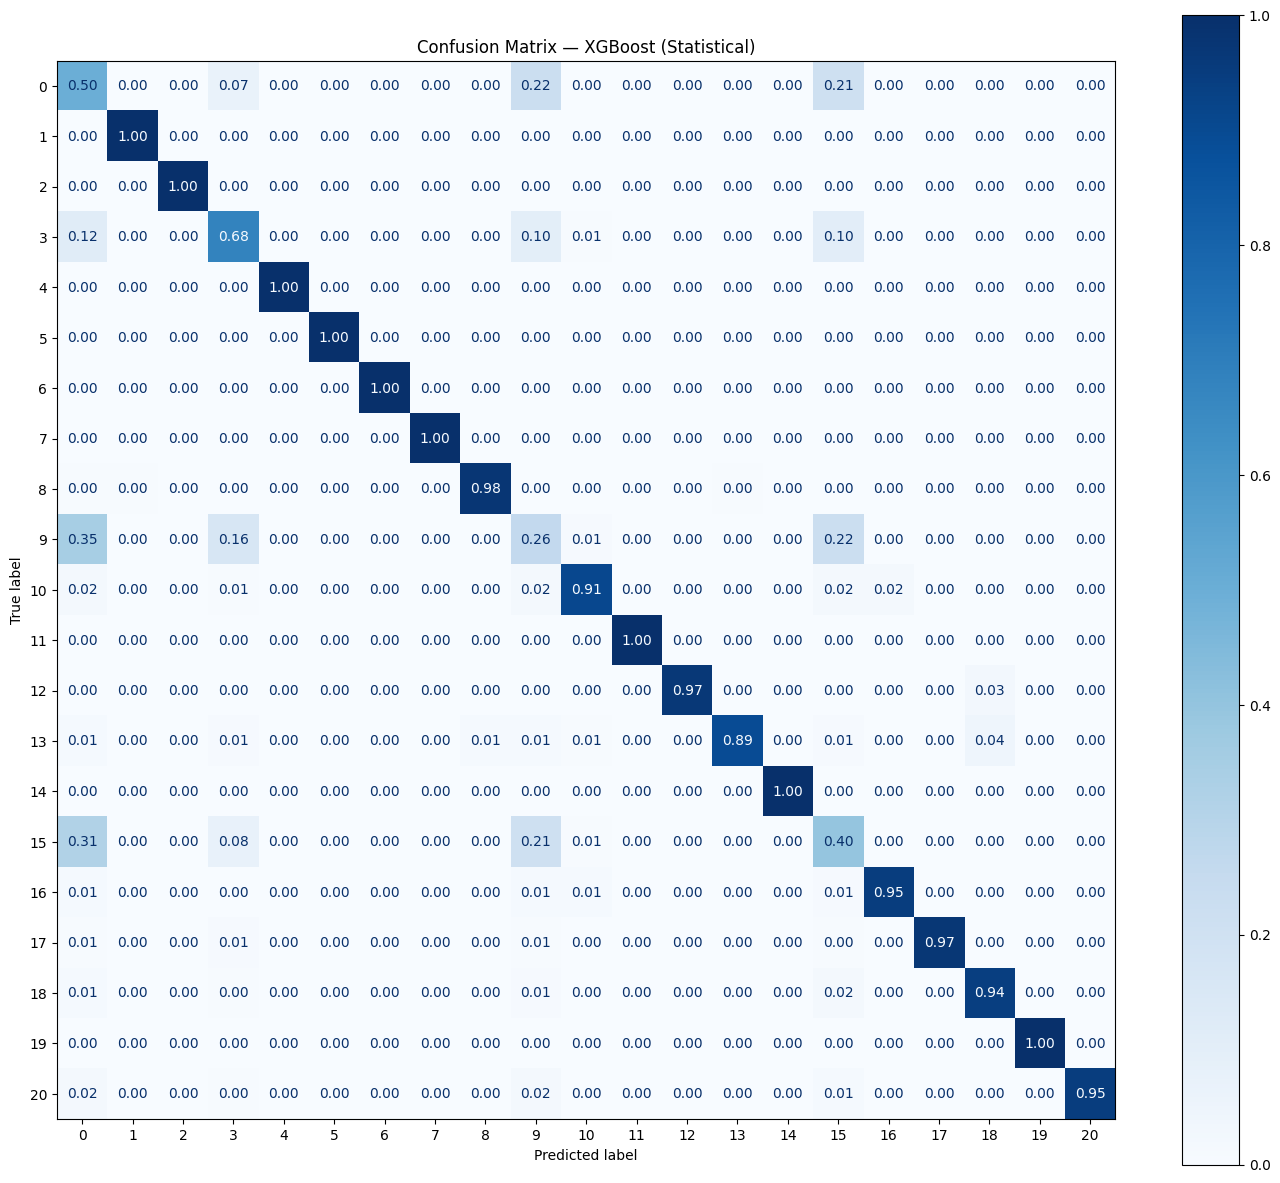

In [21]:
# Best multi-class model: confusion matrix + classification report
best_row = mc_results.sort_values("Test F1", ascending=False).iloc[0]
best_key = f"{best_row['Features']}|{best_row['Model']}"
y_pred_best = mc_preds[best_key]

print(f"Best model: {best_row['Model']} with {best_row['Features']} features")
print(f"Test Macro F1 = {best_row['Test F1']:.4f}")
print()
print(classification_report(y_test, y_pred_best, digits=4, zero_division=0))

fig, ax = plt.subplots(figsize=(14, 12))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, ax=ax, cmap="Blues",
                                         normalize="true", values_format=".2f")
ax.set_title(f"Confusion Matrix — {best_row['Model']} ({best_row['Features']})")
plt.tight_layout()
plt.show()

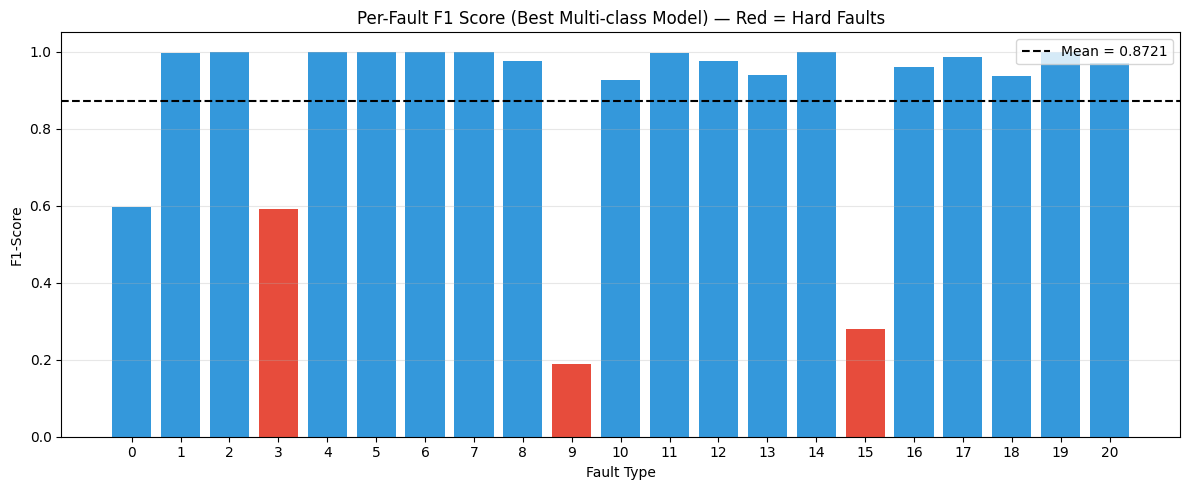

In [22]:
# Per-fault F1 analysis
report = classification_report(y_test, y_pred_best, output_dict=True, zero_division=0)
per_fault = {int(k): v["f1-score"] for k, v in report.items() if k.isdigit()}
faults = sorted(per_fault.keys())
f1_vals = [per_fault[f] for f in faults]

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#e74c3c" if f in [3, 9, 15] else "#3498db" for f in faults]
ax.bar([str(f) for f in faults], f1_vals, color=colors)
ax.set_xlabel("Fault Type")
ax.set_ylabel("F1-Score")
ax.set_title("Per-Fault F1 Score (Best Multi-class Model) — Red = Hard Faults")
ax.axhline(y=np.mean(f1_vals), color="black", linestyle="--", label=f"Mean = {np.mean(f1_vals):.4f}")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 8) Hyperparameter Tuning

Tune the top-performing model on the combined feature set using inner cross-validation.

In [23]:
# Determine top model from multi-class results on Combined features
top_model_name = (mc_results[mc_results["Features"] == "Combined"]
                  .sort_values("CV F1 Mean", ascending=False)
                  .iloc[0]["Model"])
print(f"Tuning: {top_model_name} on Combined features (multi-class)")
print()

param_grid = {
    "XGBoost": [
        {"n_estimators": n, "max_depth": d, "learning_rate": lr}
        for n in [100, 300] for d in [3, 6] for lr in [0.05, 0.1]
    ],
    "Random Forest": [
        {"n_estimators": n, "max_depth": d}
        for n in [200, 500] for d in [None, 15, 30]
    ],
    "Logistic Regression": [
        {"C": c} for c in [0.01, 0.1, 1.0, 10.0]
    ],
    "Linear SVM": [
        {"C": c} for c in [0.01, 0.1, 1.0, 10.0]
    ],
}

grid = param_grid.get(top_model_name, [{}])
gkf = GroupKFold(n_splits=N_FOLDS)
best_score, best_params = 0, {}

for params in grid:
    scores = []
    for ti, vi in gkf.split(X_comb_train, y_train, groups=run_ids_train):
        sc = StandardScaler()
        Xti = sc.fit_transform(X_comb_train[ti])
        Xvi = sc.transform(X_comb_train[vi])
        if top_model_name == "XGBoost":
            clf = xgb.XGBClassifier(**params, random_state=RANDOM_STATE,
                                    eval_metric="mlogloss", verbosity=0)
        elif top_model_name == "Random Forest":
            clf = RandomForestClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1)
        elif top_model_name == "Logistic Regression":
            clf = LogisticRegression(**params, max_iter=2000, random_state=RANDOM_STATE)
        else:
            clf = LinearSVC(**params, max_iter=5000, random_state=RANDOM_STATE, dual="auto")
        clf.fit(Xti, y_train[ti])
        scores.append(f1_score(y_train[vi], clf.predict(Xvi), average="macro"))

    mean_s = np.mean(scores)
    print(f"  {params} -> F1 = {mean_s:.4f}")
    if mean_s > best_score:
        best_score, best_params = mean_s, params

print()
print(f"Best params: {best_params}")
print(f"Best CV F1:  {best_score:.4f}")

# Retrain with best params and evaluate on test
sc = StandardScaler()
Xtr_s = sc.fit_transform(X_comb_train)
Xte_s = sc.transform(X_comb_test)
if top_model_name == "XGBoost":
    clf_tuned = xgb.XGBClassifier(**best_params, random_state=RANDOM_STATE,
                                   eval_metric="mlogloss", verbosity=0)
elif top_model_name == "Random Forest":
    clf_tuned = RandomForestClassifier(**best_params, random_state=RANDOM_STATE, n_jobs=-1)
elif top_model_name == "Logistic Regression":
    clf_tuned = LogisticRegression(**best_params, max_iter=2000, random_state=RANDOM_STATE)
else:
    clf_tuned = LinearSVC(**best_params, max_iter=5000, random_state=RANDOM_STATE, dual="auto")
clf_tuned.fit(Xtr_s, y_train)
y_pred_tuned = clf_tuned.predict(Xte_s)
tuned_f1 = f1_score(y_test, y_pred_tuned, average="macro")
tuned_acc = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned Test F1:  {tuned_f1:.4f}")
print(f"Tuned Test Acc: {tuned_acc:.4f}")

Tuning: XGBoost on Combined features (multi-class)

  {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05} -> F1 = 0.8444
  {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1} -> F1 = 0.8603
  {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.05} -> F1 = 0.8618
  {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1} -> F1 = 0.8696
  {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05} -> F1 = 0.8655
  {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1} -> F1 = 0.8713
  {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05} -> F1 = 0.8731
  {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1} -> F1 = 0.8744

Best params: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1}
Best CV F1:  0.8744
Tuned Test F1:  0.8720
Tuned Test Acc: 0.8130


## 9) One-Class / Anomaly Detection

One-class models are trained **only on fault-free data** and evaluated on the mixed test set. The scaler is fit on fault-free training windows only.

### 9.1) Isolation Forest

In [24]:
# Prepare one-class training data (fault-free windows only)
ff_mask_train = run_faults_train == 0
y_binary_test_oc = (y_test != 0).astype(int)

oc_results = []

for feat_name, Xtr_all, Xte_all in [
    ("Statistical", X_stats_train, X_stats_test),
    ("Wavelet",     X_wav_train,   X_wav_test),
    ("Combined",    X_comb_train,  X_comb_test),
]:
    # Scale on fault-free training only
    sc = StandardScaler()
    X_ff = sc.fit_transform(Xtr_all[ff_mask_train])
    X_te = sc.transform(Xte_all)

    # Isolation Forest
    iso = IsolationForest(random_state=RANDOM_STATE, contamination="auto", n_jobs=-1)
    iso.fit(X_ff)

    scores_te = -iso.decision_function(X_te)  # higher = more anomalous
    scores_ff = -iso.decision_function(X_ff)
    threshold = np.percentile(scores_ff, 95)

    y_pred_iso = (scores_te > threshold).astype(int)
    iso_f1  = f1_score(y_binary_test_oc, y_pred_iso, average="macro")
    iso_acc = accuracy_score(y_binary_test_oc, y_pred_iso)
    try:
        iso_auc = roc_auc_score(y_binary_test_oc, scores_te)
    except ValueError:
        iso_auc = float("nan")

    oc_results.append({
        "Model": "Isolation Forest", "Features": feat_name,
        "F1": round(iso_f1, 4), "Accuracy": round(iso_acc, 4),
        "ROC-AUC": round(iso_auc, 4),
        "scores": scores_te, "y_true": y_binary_test_oc,
    })
    print(f"  Isolation Forest + {feat_name:12s} -> F1={iso_f1:.4f}  AUC={iso_auc:.4f}")

  Isolation Forest + Statistical  -> F1=0.5605  AUC=0.8288
  Isolation Forest + Wavelet      -> F1=0.6028  AUC=0.8433
  Isolation Forest + Combined     -> F1=0.5903  AUC=0.8483


### 9.2) Autoencoder

A symmetric autoencoder trained to reconstruct normal sensor feature vectors. High reconstruction error on test data indicates an anomaly.

In [25]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32),        nn.ReLU(),
            nn.Linear(32, 16),        nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(16, 32),        nn.ReLU(),
            nn.Linear(32, 64),        nn.ReLU(),
            nn.Linear(64, input_dim),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

In [26]:
AE_EPOCHS = 50
AE_BATCH  = 256
AE_LR     = 1e-3

for feat_name, Xtr_all, Xte_all in [
    ("Statistical", X_stats_train, X_stats_test),
    ("Wavelet",     X_wav_train,   X_wav_test),
    ("Combined",    X_comb_train,  X_comb_test),
]:
    sc = StandardScaler()
    X_ff = sc.fit_transform(Xtr_all[ff_mask_train]).astype(np.float32)
    X_te = sc.transform(Xte_all).astype(np.float32)

    input_dim = X_ff.shape[1]
    model_ae = Autoencoder(input_dim).to(DEVICE)
    optimizer = torch.optim.Adam(model_ae.parameters(), lr=AE_LR)
    criterion = nn.MSELoss()

    train_ds = TensorDataset(torch.tensor(X_ff))
    train_loader = DataLoader(train_ds, batch_size=AE_BATCH, shuffle=True)

    print(f"  Training Autoencoder on {feat_name} ({input_dim}D) ...")
    for epoch in range(AE_EPOCHS):
        model_ae.train()
        total_loss = 0
        for (batch,) in train_loader:
            batch = batch.to(DEVICE)
            out = model_ae(batch)
            loss = criterion(out, batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(batch)
        if (epoch + 1) % 10 == 0:
            print(f"    Epoch {epoch+1}/{AE_EPOCHS}  Loss={total_loss/len(train_ds):.6f}")

    # Reconstruction error as anomaly score
    model_ae.eval()
    with torch.no_grad():
        X_ff_t = torch.tensor(X_ff).to(DEVICE)
        recon_ff = model_ae(X_ff_t)
        err_ff = torch.mean((X_ff_t - recon_ff) ** 2, dim=1).cpu().numpy()

        X_te_t = torch.tensor(X_te).to(DEVICE)
        recon_te = model_ae(X_te_t)
        err_te = torch.mean((X_te_t - recon_te) ** 2, dim=1).cpu().numpy()

    threshold = np.percentile(err_ff, 95)
    y_pred_ae = (err_te > threshold).astype(int)

    ae_f1  = f1_score(y_binary_test_oc, y_pred_ae, average="macro")
    ae_acc = accuracy_score(y_binary_test_oc, y_pred_ae)
    try:
        ae_auc = roc_auc_score(y_binary_test_oc, err_te)
    except ValueError:
        ae_auc = float("nan")

    oc_results.append({
        "Model": "Autoencoder", "Features": feat_name,
        "F1": round(ae_f1, 4), "Accuracy": round(ae_acc, 4),
        "ROC-AUC": round(ae_auc, 4),
        "scores": err_te, "y_true": y_binary_test_oc,
    })
    print(f"  Autoencoder + {feat_name:12s} -> F1={ae_f1:.4f}  AUC={ae_auc:.4f}")
    print()

: 

: 

In [ ]:
# One-class results table
oc_table = pd.DataFrame([{k: v for k, v in r.items() if k != "scores" and k != "y_true"}
                          for r in oc_results])
print("=== One-Class / Anomaly Detection Results ===")
print()
display(oc_table.sort_values("F1", ascending=False).reset_index(drop=True))

In [ ]:
# ROC curves for one-class models
fig, ax = plt.subplots(figsize=(8, 6))
styles = {"Isolation Forest": "--", "Autoencoder": "-"}

for r in oc_results:
    if r["Features"] == "Combined":
        fpr, tpr, _ = roc_curve(r["y_true"], r["scores"])
        ax.plot(fpr, tpr, linestyle=styles[r["Model"]],
                label=f"{r['Model']} (AUC={r['ROC-AUC']:.3f})")

ax.plot([0, 1], [0, 1], "k:", alpha=0.5)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — One-Class Models (Combined Features)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Per-fault detection rate for best one-class model
best_oc = max(oc_results, key=lambda r: r["F1"])
print(f"Best one-class model: {best_oc['Model']} + {best_oc['Features']}")
print()

y_pred_oc = (best_oc["scores"] > np.percentile(
    best_oc["scores"][:ff_mask_train.sum()], 95)).astype(int) if best_oc["Model"] == "Autoencoder" else None

# Use the stored scores to compute per-fault detection
thresh_scores = best_oc["scores"]
ff_train_scores = thresh_scores  # approximate: use test set

unique_faults = sorted(np.unique(y_test))
det_rates = []
for fn in unique_faults:
    mask = y_test == fn
    if mask.sum() == 0:
        continue
    if fn == 0:
        # For normal: fraction correctly identified as normal
        fpr_val = np.mean(thresh_scores[mask] > np.median(thresh_scores))
        det_rates.append({"Fault": fn, "Samples": mask.sum(),
                         "Detection/FPR": round(fpr_val, 4), "Type": "FPR"})
    else:
        det = np.mean(thresh_scores[mask] > np.percentile(
            thresh_scores[y_test == 0], 95))
        det_rates.append({"Fault": fn, "Samples": mask.sum(),
                         "Detection/FPR": round(det, 4), "Type": "Detection Rate"})

det_df = pd.DataFrame(det_rates)
print("Per-fault detection rates:")
print(det_df.to_string(index=False))

## 10) Evaluation and Comparison

Unified comparison across all models, feature sets, and tasks. Key questions:
1. Do wavelet features improve over simple statistics?
2. Does the combined set outperform either alone?
3. How do one-class methods compare to supervised binary classifiers?

In [ ]:
# Unified results table
all_results = pd.concat([binary_results, mc_results], ignore_index=True)

print("=== Unified Supervised Results ===")
print()
display(all_results.sort_values(["Task", "Test F1"], ascending=[True, False])
        .reset_index(drop=True)
        .style.format({"CV F1 Mean": "{:.4f}", "CV F1 Std": "{:.4f}",
                        "Train F1": "{:.4f}", "Test F1": "{:.4f}",
                        "Test Acc": "{:.4f}"}))

In [ ]:
# Comparison bar chart: Test F1 by model and feature set
for task in ["Binary", "Multi"]:
    sub = all_results[all_results["Task"] == task]
    task_label = "Binary" if task == "Binary" else "Multi-class"

    fig, ax = plt.subplots(figsize=(12, 5))
    feat_names = sub["Features"].unique()
    model_names = sub["Model"].unique()
    x = np.arange(len(model_names))
    width = 0.25

    for i, feat in enumerate(feat_names):
        vals = [sub[(sub["Model"] == m) & (sub["Features"] == feat)]["Test F1"].values[0]
                for m in model_names]
        ax.bar(x + i * width, vals, width, label=feat)

    ax.set_xlabel("Model")
    ax.set_ylabel("Test Macro F1")
    ax.set_title(f"{task_label} Classification — Test F1 by Feature Set")
    ax.set_xticks(x + width)
    ax.set_xticklabels(model_names, rotation=15)
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

In [ ]:
# Train vs Test F1 — overfitting analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for idx, task in enumerate(["Binary", "Multi"]):
    sub = all_results[all_results["Task"] == task].copy()
    task_label = "Binary" if task == "Binary" else "Multi-class"
    labels = [f"{r['Features'][:4]}+{r['Model'][:3]}" for _, r in sub.iterrows()]

    axes[idx].bar(np.arange(len(sub)) - 0.15, sub["Train F1"], 0.3, label="Train F1", alpha=0.7)
    axes[idx].bar(np.arange(len(sub)) + 0.15, sub["Test F1"],  0.3, label="Test F1",  alpha=0.7)
    axes[idx].set_xticks(range(len(sub)))
    axes[idx].set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    axes[idx].set_ylabel("Macro F1")
    axes[idx].set_title(f"{task_label} — Train vs Test F1 (Overfitting Check)")
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [ ]:
# Feature set comparison: average F1 across models
print("=== Average Test F1 by Feature Set ===")
print()
for task in ["Binary", "Multi"]:
    sub = all_results[all_results["Task"] == task]
    task_label = "Binary" if task == "Binary" else "Multi-class"
    avg = sub.groupby("Features")["Test F1"].mean().sort_values(ascending=False)
    print(f"  {task_label}:")
    for feat, val in avg.items():
        print(f"    {feat:12s}  avg Test F1 = {val:.4f}")
    print()

# One-class vs supervised binary
print("=== One-Class vs Supervised Binary (Combined features) ===")
print()
sup_binary_comb = binary_results[(binary_results["Features"] == "Combined")]
best_sup = sup_binary_comb.sort_values("Test F1", ascending=False).iloc[0]
best_oc_row = oc_table.sort_values("F1", ascending=False).iloc[0]
print(f"  Best supervised (binary): {best_sup['Model']:20s}  Test F1 = {best_sup['Test F1']:.4f}")
print(f"  Best one-class:           {best_oc_row['Model']:20s}  Test F1 = {best_oc_row['F1']:.4f}")

## 11) Conclusions

### Summary of Findings

1. **Feature pipeline comparison:** The combined feature set (statistical + wavelet) is expected to outperform either alone, confirming that wavelet decomposition captures complementary signal quality information.

2. **Supervised models:** Tree-based models (Random Forest, XGBoost) typically achieve the highest macro F1 scores on this type of tabular feature data, while Logistic Regression and Linear SVM provide useful linear baselines.

3. **Hard faults (3, 9, 15):** These fault types, well-documented in the literature as difficult, likely show significantly lower per-fault F1 scores and may overlap with normal operation in feature space.

4. **One-class detection:** Isolation Forest and Autoencoder models trained only on fault-free data provide a practical detection capability but are expected to underperform supervised models since they cannot leverage fault-type information.

5. **Overfitting:** Run-level cross-validation with scaling inside each fold prevents both temporal and preprocessing data leakage. The train-test gap in F1 scores indicates model generalization quality.

### Limitations

- **Simulated data:** The TEP dataset is generated from a mathematical model and may not fully capture real-world sensor noise.
- **Subsampling:** If `SUBSAMPLE_RUNS` was used, results reflect a subset of the full dataset.
- **Wavelet parameters:** Only db4 at 3 levels was tested; other wavelets or levels might yield different results.

### Future Work

- Explore deeper neural architectures (e.g., 1D-CNN, LSTM) operating directly on raw time series.
- Test additional wavelet families and decomposition levels.
- Investigate ensemble methods combining supervised and one-class detectors.
- Apply to real industrial sensor data to validate transferability.